# Data Preprocessing
This notebook starts with downloading the dataset and then performs data preprocessing steps to create a clean dataset for further analysis.

## Imports

In [5]:
from tqdm import tqdm
import csv
import pandas as pd
import csv
import math
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict

# Dowloaded and extracted Stuttgart 0.88 B Version of SDEWAC German Corpus and renamed from .tagged to .txt
data_path = "data/sdewac-v3.txt" 

## Take 1 MIO Sentences of the dataset (only run if you want to test the code with a smaller dataset)

In [8]:
sentences_count = 1000000
output_path = f"data/sdewac-v3_{sentences_count}.txt"
sentence_counter = 0

with open(data_path, "r", encoding="utf-8") as f_in, \
     open(output_path, "w", encoding="utf-8") as f_out:
    
    for line in f_in:
        f_out.write(line)
        if "</sentence>" in line:
            sentence_counter += 1
            if sentence_counter >= sentences_count:
                break

print(f"Saved first {sentence_counter} sentences to: {output_path}")
data_path = output_path

Saved first 0 sentences to: data/sdewac-v3_1000000.txt


## Calculate Corpus Wide Metrics for each Keyword

Runs 14 sec with 100k sentences and 90 sec with 1 MIO sentences on my MAC M4

In [7]:
# 1. Keyword-Setup
keywords_csv = "keyword_groundtruth.csv"
output_csv = "data/keywords_metrics.csv"

keyword_variants = []
score_map = {}
max_kw_len = 1 # for this dataset will be 3

# Read keywords and their scores from CSV and save the max keyword length for the window size
with open(keywords_csv, encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader) # Skip header
    for row in reader:
        kw, score = row[0].strip(), row[1].strip()
        if not kw:
            continue
        variants = [v.lower() for v in kw.split('/')] # Split by '/' to get variants
        variant_tokens = [tuple(v.split()) for v in variants] # Split each variant into tokens
        for vt in variant_tokens: # Ensure each variant is a tuple of tokens
            max_kw_len = max(max_kw_len, len(vt)) # Update max keyword length
        key = '/'.join(variants)
        keyword_variants.append((variant_tokens, key))
        score_map[key] = float(score)

# Build variant-tuple → key lookup
variant_tuple_to_key = {}
for variant_tokens, key in keyword_variants:
    for vt in variant_tokens:
        variant_tuple_to_key[vt] = key

# 2. Word and Tag Extraction for Sliding Window Matching
tokens_tags = []
print("Reading tokens and tags...")
with open(data_path, encoding="utf-8") as f:
    for line in tqdm(f, desc="Reading file"):
        line = line.strip()
        if not line or line.startswith("<"):
            continue
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        tok = parts[0].lower()
        tag = parts[1]
        tokens_tags.append((tok, tag))

# 3. Sliding Window Matching: Counting Variants
# defaultdicts will perform better for counting
freq = defaultdict(int)
contexts = defaultdict(list)
pre_tags = defaultdict(set)
post_tags = defaultdict(set)
token_counts = defaultdict(int)
bigram_counts = defaultdict(int)
total_tokens = len(tokens_tags)

# Calculate total iterations for progress bar
total_iterations = 0
for i in range(total_tokens):
    for n in range(1, max_kw_len+1):
        if i + n <= total_tokens:
            total_iterations += 1

# Counts für Tokens
print("Counting tokens...")
for tok, _ in tqdm(tokens_tags, desc="Token counting"):
    token_counts[tok] += 1

print("Sliding window matching...")
current_iteration = 0
for i in tqdm(range(total_tokens), desc="Sliding window"):
    # Check alle möglichen Längen von 1 bis max_kw_len
    for n in range(1, max_kw_len+1):
        if i + n > total_tokens:
            continue
        window = tuple(tok for tok, _ in tokens_tags[i:i+n])
        if window in variant_tuple_to_key:
            key = variant_tuple_to_key[window]
            freq[key] += 1

            # context token before if exists
            if i > 0:
                prev_tok, prev_tag = tokens_tags[i-1]
                contexts[key].append(prev_tok)
                pre_tags[key].add(prev_tag)
                bigram_counts[(key, prev_tok)] += 1
            # context token after if exists
            if i + n < total_tokens:
                next_tok, next_tag = tokens_tags[i+n]
                contexts[key].append(next_tok)
                post_tags[key].add(next_tag)
                bigram_counts[(key, next_tok)] += 1
            # no counting two times the same variant in the same sentence
            break

# 4. Metriken berechnen wie gehabt
rows = []
if freq:
    max_occ = max(freq.values())
    min_occ = min(freq.values())
    occ_range = max_occ - min_occ or 1
else:
    max_occ = min_occ = occ_range = 1

print("Calculating metrics...")
for variant_tokens, key in tqdm([(vt, k) for vtlist, k in keyword_variants for vt in vtlist], desc="Metrics calculation"):
    k_freq = freq[key]
    norm_occ = (1.0 if k_freq == max_occ else
                0.0 if k_freq == min_occ else
                (k_freq - min_occ) / occ_range)
    avg_len = sum(len(tok) for tok in variant_tokens) / len(variant_tokens)
    ctx_ent = len(set(contexts[key]))
    sca = len(pre_tags[key]) + len(post_tags[key])

    # Collocation Strength (PMI)
    weighted_pmi_sum = 0.0
    for (w, c), bc in bigram_counts.items():
        if w != key:
            continue
        p_wc = bc / max(total_tokens-1, 1)
        p_w = k_freq / total_tokens if k_freq > 0 else 1 / total_tokens
        p_c = token_counts.get(c, 1) / total_tokens
        pmi = math.log2(p_wc / (p_w * p_c) + 1e-12)
        weighted_pmi_sum += pmi * bc
    col_str = weighted_pmi_sum / k_freq if k_freq > 0 else 0.0
    gramm_score = score_map.get(key, None)

    rows.append({
        "keyword": key,
        "occurrences": k_freq,
        "normalized_occurrences": norm_occ,
        "avg_length": avg_len,
        "context_entropy": ctx_ent,
        "collocation_strength": col_str,
        "synthetic_context_adversity": sca,
        "gramm_score": gramm_score
    })

# 5. Speichern
df = pd.DataFrame(rows).sort_values("occurrences", ascending=False)
df.to_csv(output_csv, index=False)
print(f"Wrote {len(df)} rows (multi-token exakte Matches!) to {output_csv}")

Reading tokens and tags...


Reading file: 39984790it [00:14, 2751960.73it/s]


Counting tokens...


Token counting: 100%|██████████| 33006370/33006370 [00:05<00:00, 5811740.95it/s]


Sliding window matching...


Sliding window: 100%|██████████| 33006370/33006370 [00:36<00:00, 896570.94it/s]


Calculating metrics...


Metrics calculation: 100%|██████████| 235/235 [00:28<00:00,  8.21it/s]

Wrote 235 rows (multi-token exakte Matches!) to data/keywords_metrics.csv


## Analyse Keyword Metrics

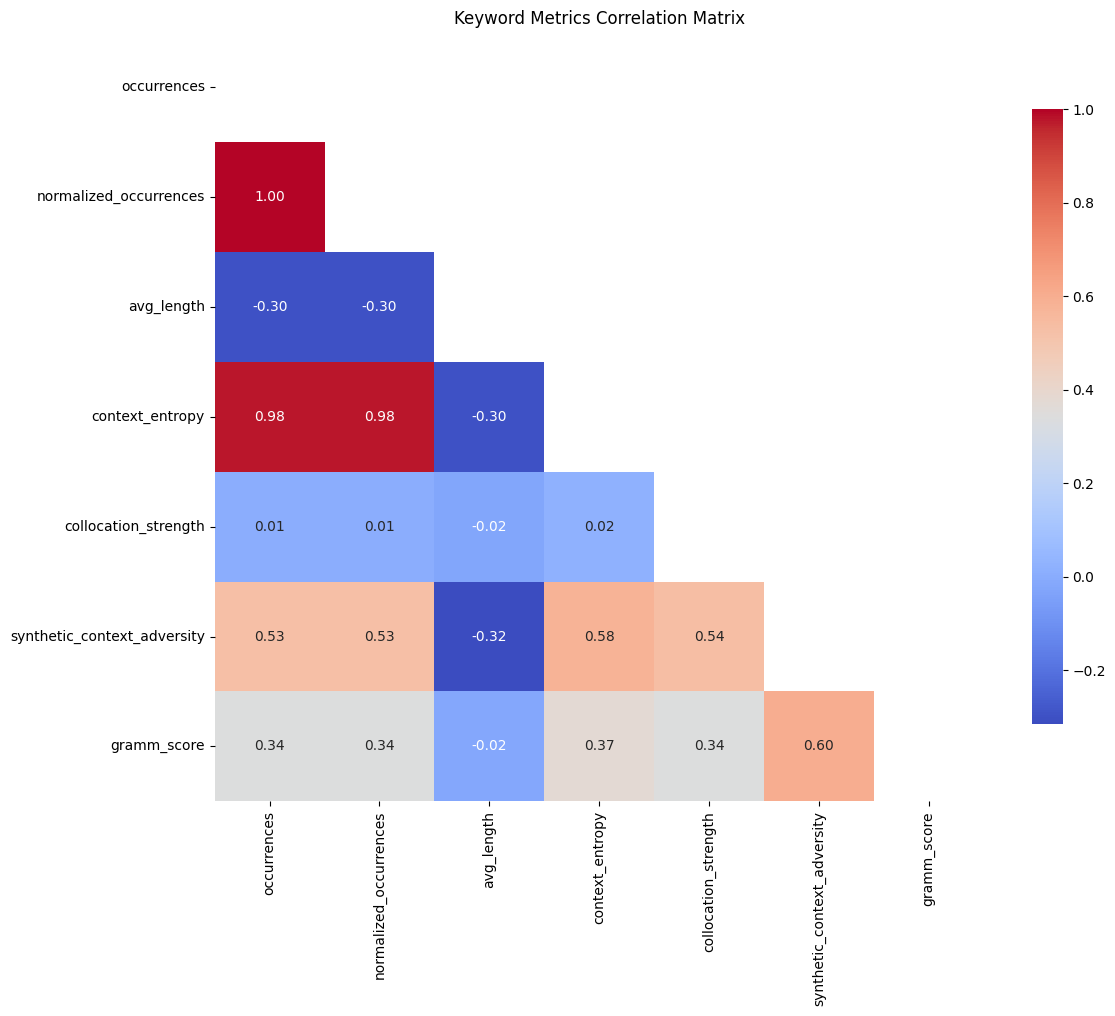

<Figure size 640x480 with 0 Axes>

In [10]:
path = "data/keywords_metrics.csv"
df = pd.read_csv(path)

corr_matrix = df.drop(columns=["keyword"]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, 
            cbar_kws={"shrink": .8}, mask=mask)
plt.title("Keyword Metrics Correlation Matrix")
plt.tight_layout()
plt.show()
plt.savefig("data/keyword_metrics_correlation_matrix.png", dpi=300)


## Extract Sentences that Contain Keywords and create json dataset that also contains the keyword metrics